### [ 블러링 - 평균 블러 ] <hr>
- 커널/마스크/필터/윈도우라고 하는 작은 행렬을 사용해서 이미지 픽셀값 조절
- 기능 
    * 이미지의 노이즈(불필요한 픽셀)을 제거
    * 이미지의 경계를 뚜렷하게 하기
- 커널에 종류에 따라 기능이 정해짐

In [1]:
import numpy as np, cv2, matplotlib.pyplot as plt, koreanize_matplotlib, sys
sys.path.append(r'C:\Users\Win11Pro\Desktop\KDT-14\[7]_CVISION')
from cv_utils import *

In [2]:
IMG_FILE = '../Data/images/taekwonv1.jpg'

In [3]:
# 이미지 데이터 로딩 및 기본 정보 확인
img = cv2.imread(IMG_FILE)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
print(f'[기본정보] shape : {img.shape}, ndim : {img.ndim}, dtype : {img.dtype}')

[기본정보] shape : (444, 400, 3), ndim : 3, dtype : uint8


blur : (444, 400, 3), 1, 224


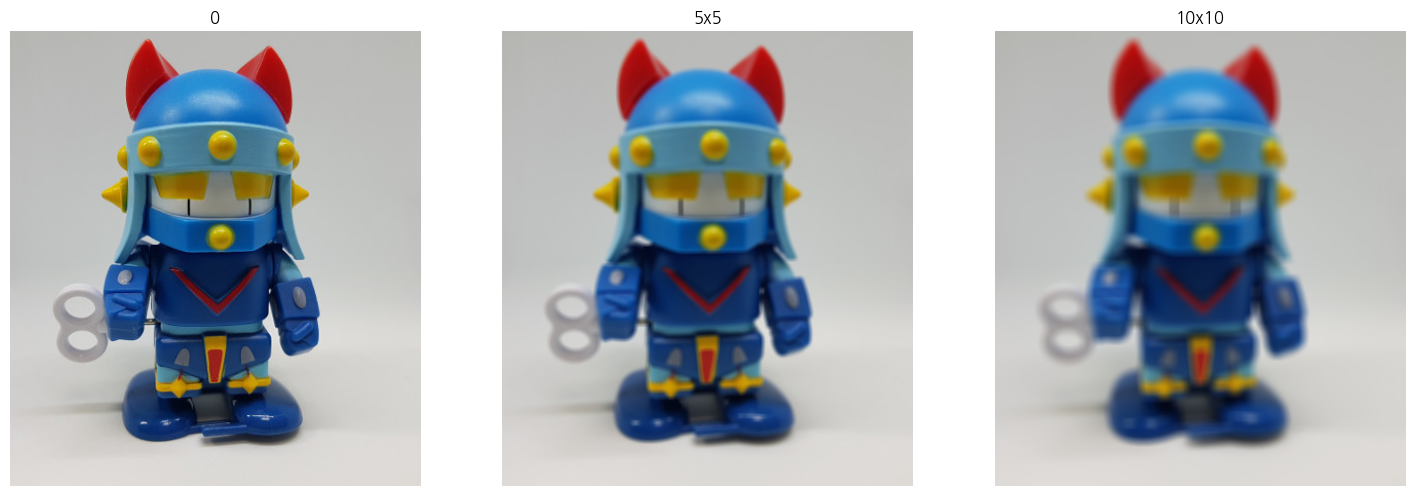

In [4]:
# 원본 & 블러 이미지 비교
# 평균 블러 처리
blur_5 = cv2.blur(img, (5,5))
blur_10 = cv2.blur(img, (10,10))
print(f'blur : {blur_5.shape}, {blur_5.min()}, {blur_5.max()}')

printPolts(1,3, ['0','5x5','10x10'], [img, blur_5, blur_10])

### [ 가우시안 블러 ] <hr>
- 가중치에 따른 값을 가지는 커널
- 중심 픽셀을 기준으로 다른 가중치 값 설정한 커널 사용
- 자연스러운 블러링


In [27]:
# 원본 & 블러 이미지 비교
# 가우시안 블러 처리
# 방법1) 커널 + 컨볼루션 연산
# => 커널 3x3
g_img = '../Data/images/gaussian_noise.jpg' 
g_img = cv2.cvtColor(cv2.imread(g_img), cv2.COLOR_BGR2RGB)
print(f'blur : {g_img.shape}, {g_img.min()}, {g_img.max()}')

kernel = np.array([[1,2,1],[2,4,2],[1,2,1]]) * (1/16)
print(kernel, sep='\n')

# => 컨볼루션 연산 수행 : 픽셀1*커널값 + ... + 픽셀9*커널값 = 합계 
conblur1 = cv2.filter2D(g_img, -1, kernel)

blur : (256, 256, 3), 0, 255
[[0.0625 0.125  0.0625]
 [0.125  0.25   0.125 ]
 [0.0625 0.125  0.0625]]


In [29]:
# 방법2) cv2 커널생성 + 컨볼루션 연산
# => 커널 3x3 , 평균 0, 표준편차 1
gKernel = cv2.getGaussianKernel(3, 0) # <- 0: 자동계산
print(gKernel, sep='\n')

conblur2 = cv2.filter2D(g_img, -1, gKernel * gKernel.T)

[[0.25]
 [0.5 ]
 [0.25]]


In [35]:
# 방법3) cv2 가우시안 블러 함수
g_blur = cv2.GaussianBlur(g_img, (3,3), 0)

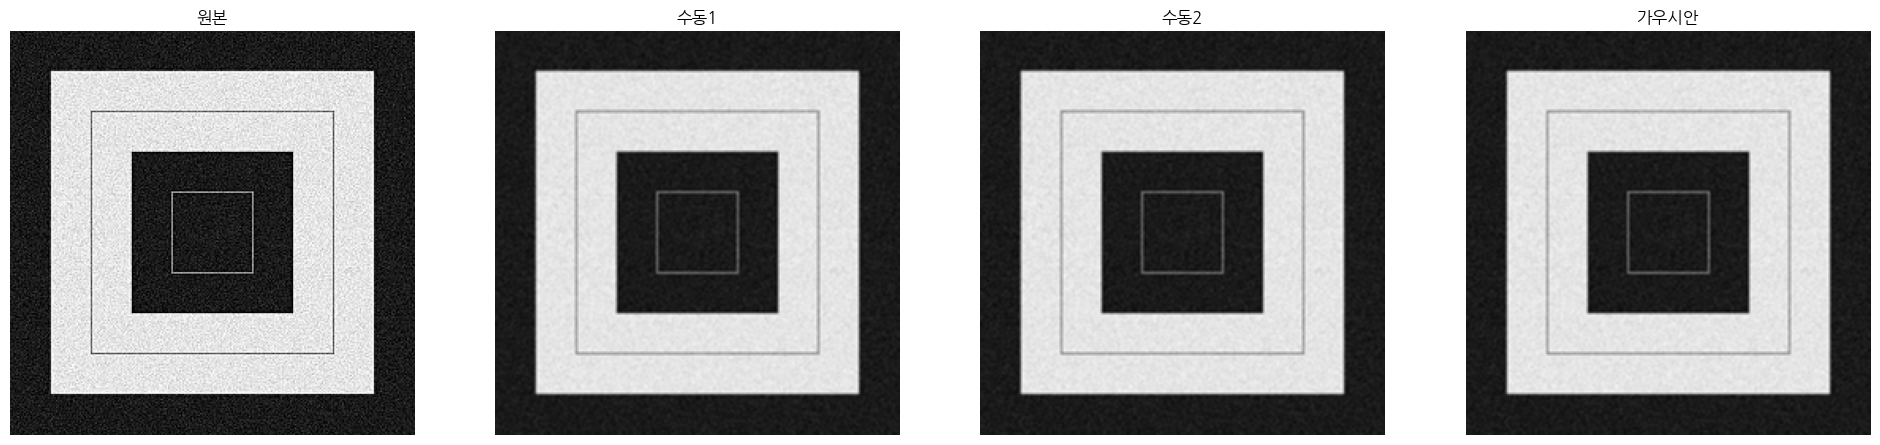

In [36]:
# 시각화
printPolts(1,4, ['원본','수동1', '수동2', '가우시안'], [g_img, conblur1, conblur2, g_blur])